### Indice MNDWI para separar pixelels de agua vs pixeles de tierra
##### Prueba de concepto

In [98]:
from pathlib import Path
import os
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import sys
import numpy as np
sys.path.append("../../external/acolite")
import acolite as ac 
import boto3
import pystac
from s2cloudless import S2PixelCloudDetector
import numpy as np
from xarray.core.dataset import Dataset

In [89]:
SHARD=3
BANDS_FOLDER = Path(f"../../data/bands/B07-B06-B05-B04-B03-B02-B01-B08-B8A-B09-B10-B11-B12/shard-{SHARD}")
matchups = gpd.read_file("../../data/registros_limpios_matchups.json")

In [96]:
muestras = [1838, 1635, 1734, 1890, 1861, 2130, 2059, 2295]

In [ ]:
muestra = muestras[1]
ds = xr.open_dataset(BANDS_FOLDER / f"{muestra}.nc")

In [92]:
rgb = ds[["B04", "B03", "B02"]].isel(time=0).to_dataarray()
rgb

<xarray.DataArray (variable: 3, y: 19, x: 16)> Size: 7kB
array([[[0.0788, 0.0782, 0.0796, 0.0792, 0.0814, 0.0814, 0.0809, 0.0807,
         0.0811, 0.0829, 0.0825, 0.0822, 0.0784, 0.0773, 0.0765, 0.0771],
        [0.0779, 0.078 , 0.0781, 0.0809, 0.0795, 0.0805, 0.0788, 0.0802,
         0.0802, 0.0834, 0.0834, 0.084 , 0.0777, 0.0781, 0.0777, 0.0763],
        [0.0777, 0.0773, 0.0774, 0.0732, 0.0657, 0.0762, 0.0804, 0.0803,
         0.0808, 0.0803, 0.0838, 0.1084, 0.1178, 0.083 , 0.0795, 0.0765],
        [0.0781, 0.0769, 0.0782, 0.078 , 0.0764, 0.0797, 0.0807, 0.0814,
         0.0799, 0.0808, 0.0828, 0.1355, 0.1287, 0.1216, 0.0876, 0.078 ],
        [0.0767, 0.077 , 0.0764, 0.0769, 0.0775, 0.083 , 0.0817, 0.0811,
         0.0809, 0.0802, 0.0832, 0.1101, 0.1329, 0.1399, 0.0895, 0.0794],
        [0.0762, 0.0765, 0.0745, 0.0719, 0.0776, 0.0785, 0.0781, 0.0809,
         0.0804, 0.0802, 0.0863, 0.1167, 0.1238, 0.1351, 0.0905, 0.0791],
        [0.0767, 0.0751, 0.0755, 0.0781, 0.0759, 0.0742, 0.0802, 0.0792,
         0.0807, 0.0796, 0.0827, 0.1005, 0.1023, 0.0991, 0.0929, 0.0785],
        [0.0756, 0.0766, 0.0775, 0.0761, 0.0745, 0.0768, 0.0799, 0.0795,
         0.0784, 0.0783, 0.0839, 0.0903, 0.0934, 0.111 , 0.0976, 0.0822],
        [0.0763, 0.0753, 0.0752, 0.0763, 0.0692, 0.063 , 0.0731, 0.0782,
         0.0776, 0.0786, 0.0778, 0.0814, 0.0823, 0.0999, 0.0862, 0.0817],
        [0.076 , 0.0753, 0.0755, 0.0776, 0.0619, 0.0495, 0.0602, 0.0698,
         0.077 , 0.0773, 0.0792, 0.0796, 0.0795, 0.0922, 0.0873, 0.0793],
...
        [0.1101, 0.1101, 0.11  , 0.1117, 0.1033, 0.0928, 0.0978, 0.1049,
         0.1098, 0.1113, 0.1134, 0.1129, 0.1129, 0.1233, 0.1219, 0.1131],
        [0.11  , 0.1105, 0.1112, 0.1112, 0.1006, 0.0944, 0.0897, 0.1026,
         0.1105, 0.1107, 0.1102, 0.1115, 0.1113, 0.1127, 0.1127, 0.1138],
        [0.1109, 0.1106, 0.111 , 0.1105, 0.103 , 0.0916, 0.0916, 0.1008,
         0.1099, 0.1102, 0.1097, 0.11  , 0.1098, 0.1098, 0.1117, 0.1162],
        [0.1111, 0.1108, 0.1101, 0.1095, 0.1049, 0.0944, 0.0976, 0.1064,
         0.1093, 0.1107, 0.1088, 0.1091, 0.1093, 0.1098, 0.1064, 0.1306],
        [0.1124, 0.1108, 0.1101, 0.11  , 0.1069, 0.1046, 0.1032, 0.1047,
         0.1075, 0.1098, 0.1094, 0.1095, 0.1084, 0.1045, 0.1121, 0.1259],
        [0.1101, 0.1105, 0.1098, 0.1106, 0.1103, 0.1081, 0.0967, 0.1028,
         0.1068, 0.1103, 0.1103, 0.1098, 0.1077, 0.1042, 0.1096, 0.1104],
        [0.1122, 0.1093, 0.1095, 0.1107, 0.1088, 0.1082, 0.1041, 0.102 ,
         0.1077, 0.1108, 0.1108, 0.1098, 0.1092, 0.1074, 0.1087, 0.1087],
        [0.1117, 0.1093, 0.1096, 0.1082, 0.1081, 0.1095, 0.1081, 0.1069,
         0.1082, 0.1081, 0.1092, 0.1085, 0.1086, 0.109 , 0.1089, 0.1087],
        [0.1115, 0.1088, 0.1086, 0.1075, 0.1082, 0.1087, 0.1079, 0.1081,
         0.1057, 0.1074, 0.1098, 0.1094, 0.1081, 0.1087, 0.1065, 0.1092],
        [0.1169, 0.1089, 0.1076, 0.1074, 0.1077, 0.1069, 0.1064, 0.1071,
         0.1048, 0.0959, 0.1007, 0.1072, 0.1089, 0.1095, 0.1095, 0.1093]]])
Coordinates:
  * variable     (variable) object 24B 'B04' 'B03' 'B02'
  * y            (y) float64 152B 6.143e+06 6.143e+06 ... 6.142e+06 6.142e+06
  * x            (x) float64 128B 6.762e+05 6.762e+05 ... 6.77e+05 6.771e+05
    spatial_ref  int32 4B ...
    time         datetime64[ns] 8B 2022-11-08T13:31:51.024000

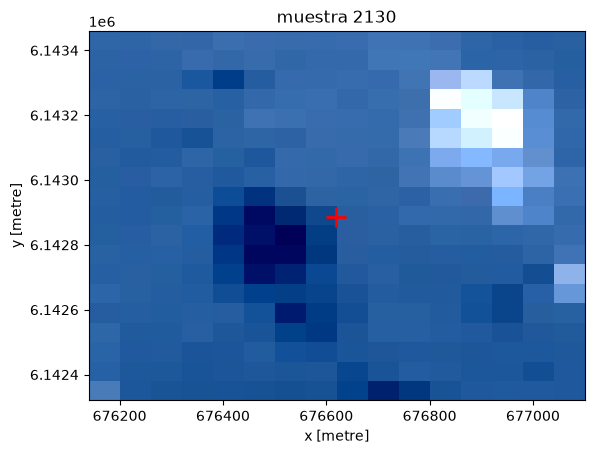

In [93]:
m = matchups.loc[muestra]
px, py = m.geometry.x, m.geometry.y
ax = rgb.plot.imshow(robust = True)
ax.axes.plot(px, py, "r+", markersize=15, markeredgewidth=2)
plt.title(f"muestra {muestra}")
plt.show()

In [99]:
def mndwi(ds: Dataset):
    B03 = ds["B03"].isel(time=0)
    B11 = ds["B11"].isel(time=0)
    mdnwi = (B03 - B11) / (B03 + B11)
    water_mask = (mdnwi > 0).to_numpy()
    water_mask = np.where(water_mask, 1, 0)
    return water_mask

water_mask = mndwi(ds)

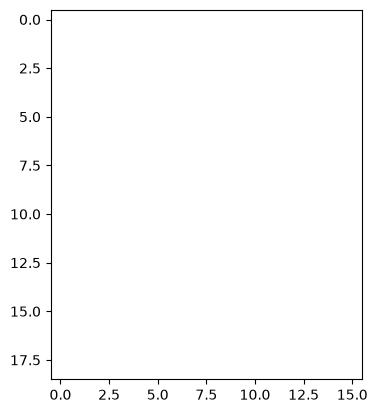

In [ ]:
plt.imshow(water_mask, cmap="gray", vmin=0, vmax=1)
plt.show()

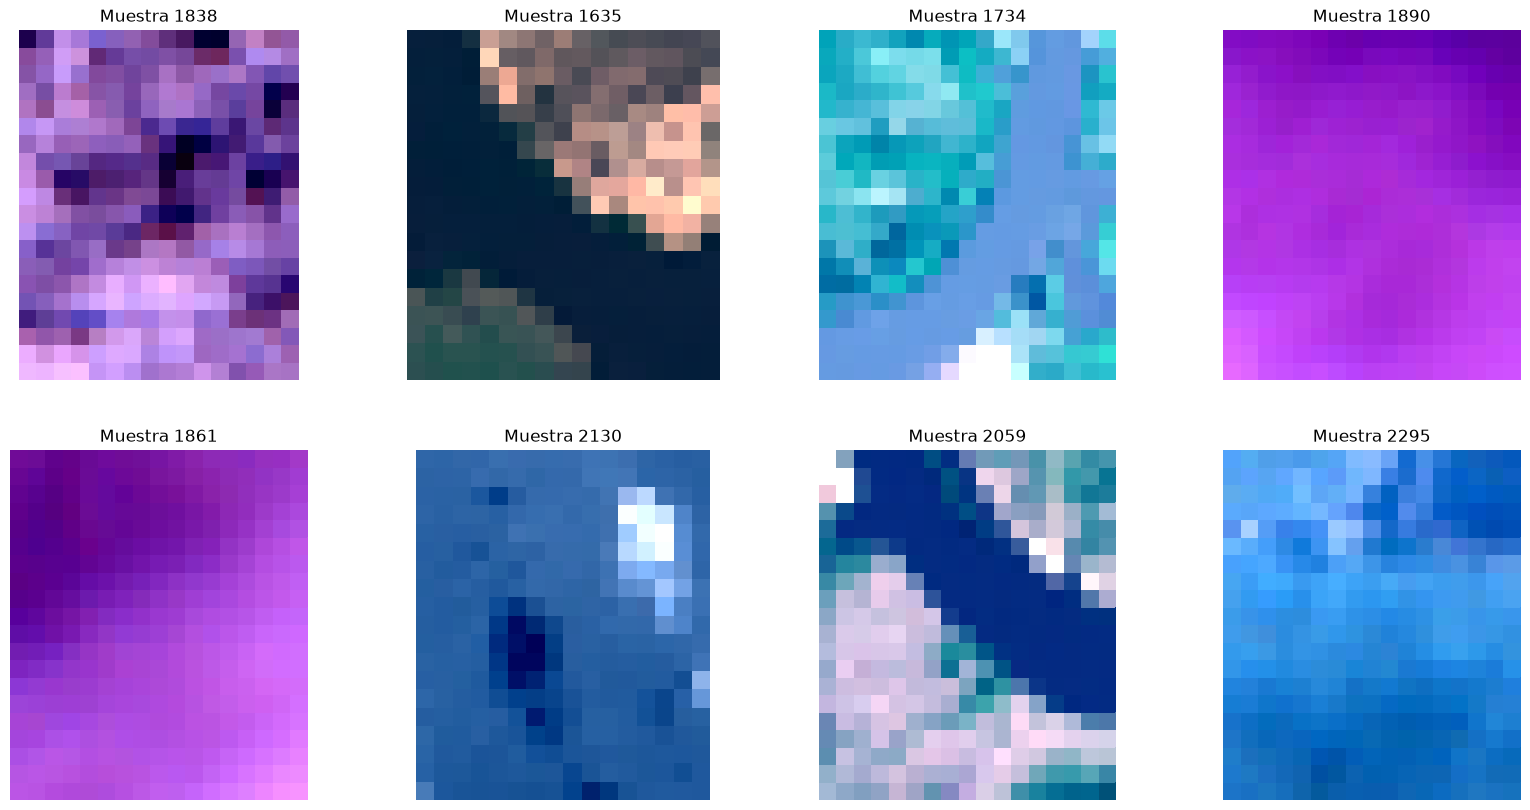

<Figure size 640x480 with 0 Axes>

In [119]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        ax = axes[i, j]
        muestra = muestras[4*i + j]
        ds = xr.open_dataset(BANDS_FOLDER / f"{muestra}.nc")
        rgb = ds[["B04", "B03", "B02"]].isel(time=0).to_dataarray().to_numpy()
        rgb = rgb.transpose(1, 2, 0)
        
          # Contrast stretch for visualization
        p2, p98 = np.nanpercentile(rgb, (2, 98))
        rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

        ax.imshow(rgb)
        ax.set_title(f"Muestra {muestra}")
        ax.axis("off")
plt.show()
plt.tight_layout()


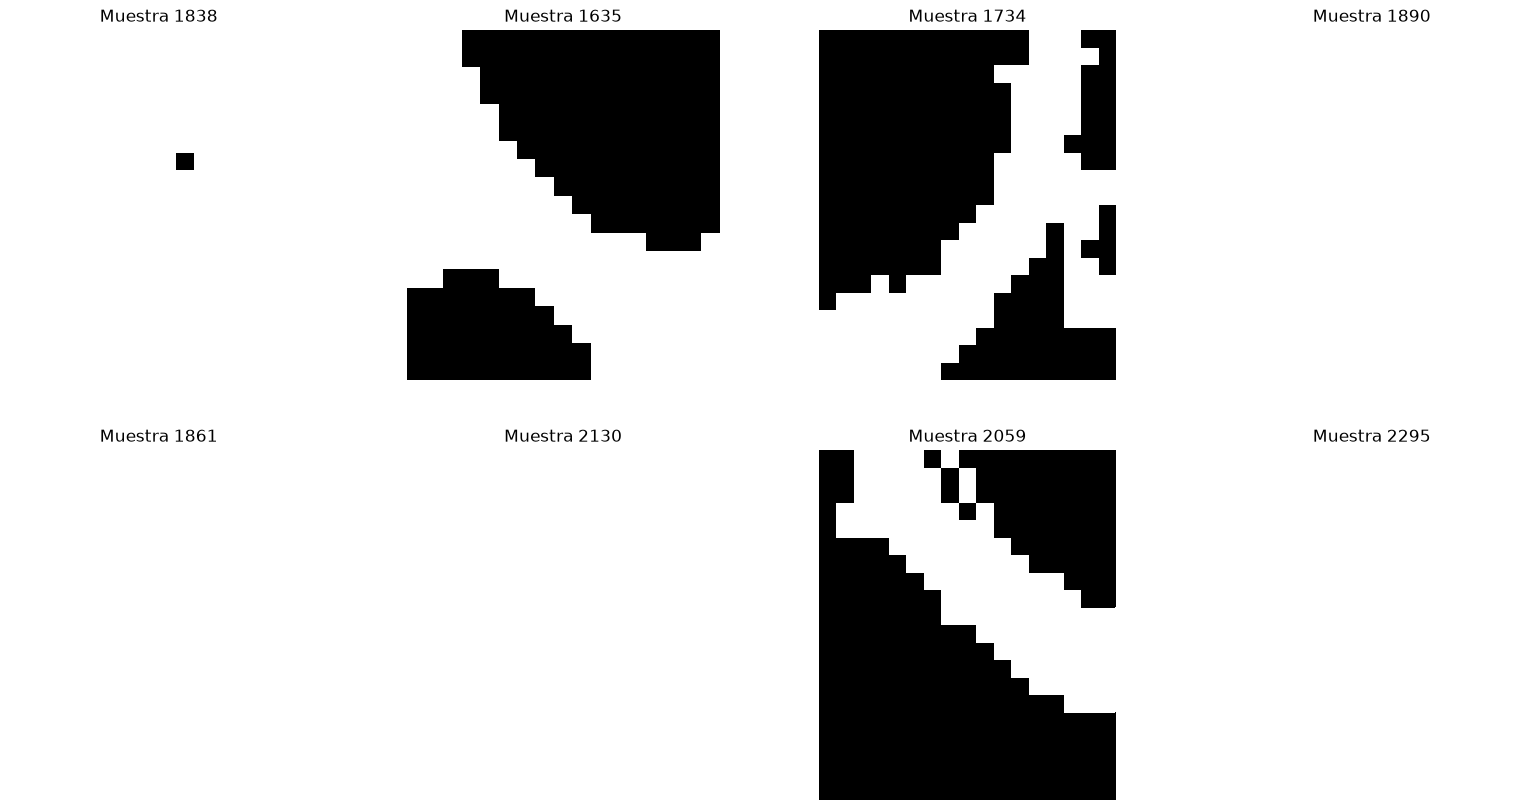

<Figure size 640x480 with 0 Axes>

In [121]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i in range(2):
    for j in range(4):
        ax = axes[i, j]
        muestra = muestras[4*i + j]
        ds = xr.open_dataset(BANDS_FOLDER / f"{muestra}.nc")
        #rgb = ds[["B04", "B03", "B02"]].isel(time=0).to_dataarray().to_numpy()
        #rgb = rgb.transpose(1, 2, 0)

        water_mask = mndwi(ds)
        
          # Contrast stretch for visualization
        #p2, p98 = np.nanpercentile(rgb, (2, 98))
        #rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

        ax.imshow(water_mask, cmap="gray", vmin=0, vmax=1)

        #ax.imshow(rgb)
        ax.set_title(f"Muestra {muestra}")
        ax.axis("off")
plt.show()
plt.tight_layout()